# **Analyse et Ingénierie des données de la chlordécone aux Antilles françaises**

# Notebook 5 – Données Spatiales & Cartes
**Projet Chlordécone – Antilles françaises**

Les coordonnées X/Y sont en projection UTM Zone 20N (système métrique). On doit les convertir en latitude/longitude pour les afficher sur une carte.

### Objectifs de ce notebook
- Convertir des coordonnées UTM → latitude/longitude avec `pyproj`
- Produire des cartes statiques de répartition spatiale
- Agréger les données par commune pour une analyse géographique
- Créer des cartes interactives (heatmap, marqueurs) avec `Folium`
- Visualiser l'évolution temporelle sur carte

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import os

# Chemins relatifs pour la reproductibilité
NOTEBOOK_DIR = os.getcwd()
FIG_DIR = os.path.join(NOTEBOOK_DIR, 'fig', '5-donnees_spatiales')
os.makedirs(FIG_DIR, exist_ok=True)

# Chargement du dataset (séparateur point-virgule, format français)
df = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'BaseCLD2026.csv'),
    sep=';',
    parse_dates=['Date_prelevement', 'Date_enregistrement', 'Date_analyse']
)

# Conversion numérique des colonnes qui peuvent être lues comme str
cols_numeriques = ['Taux_Chlordecone', 'Taux_5b_hydro', 'histoBanane_Histo_ban',
                   'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean',
                   'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean',
                   'X', 'Y']
for col in cols_numeriques:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['log_Taux'] = np.log1p(df['Taux_Chlordecone'])

print(f'Données chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Données chargées : 31,126 lignes × 23 colonnes


C:\Users\patxi\AppData\Local\Temp\ipykernel_22056\33989351.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(
C:\Users\patxi\AppData\Local\Temp\ipykernel_22056\33989351.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(
C:\Users\patxi\AppData\Local\Temp\ipykernel_22056\33989351.py:14: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


## 1. Conversion UTM → Latitude/Longitude

On utilise `pyproj` pour convertir les coordonnées X/Y en degrés décimaux.

In [2]:
# Importation de pyproj pour la transformation des coordonnées
from pyproj import Transformer

# Pour faciliter les analyses spatiales, on convertit les coordonnées X et Y du système de référence EPSG:4559 en latitude et longitude (EPSG:4326)
# Transformation des coordonnées
transformer = Transformer.from_crs('EPSG:4559', 'EPSG:4326', always_xy=True)
df['lon'], df['lat'] = transformer.transform(df['X'].values, df['Y'].values)


print(f'Latitude  : {df["lat"].min():.3f} → {df["lat"].max():.3f}')
print(f'Longitude : {df["lon"].min():.3f} → {df["lon"].max():.3f}')

Latitude  : 14.412 → 14.876
Longitude : -61.228 → -60.826


## 2. Carte statique – Répartition des parcelles

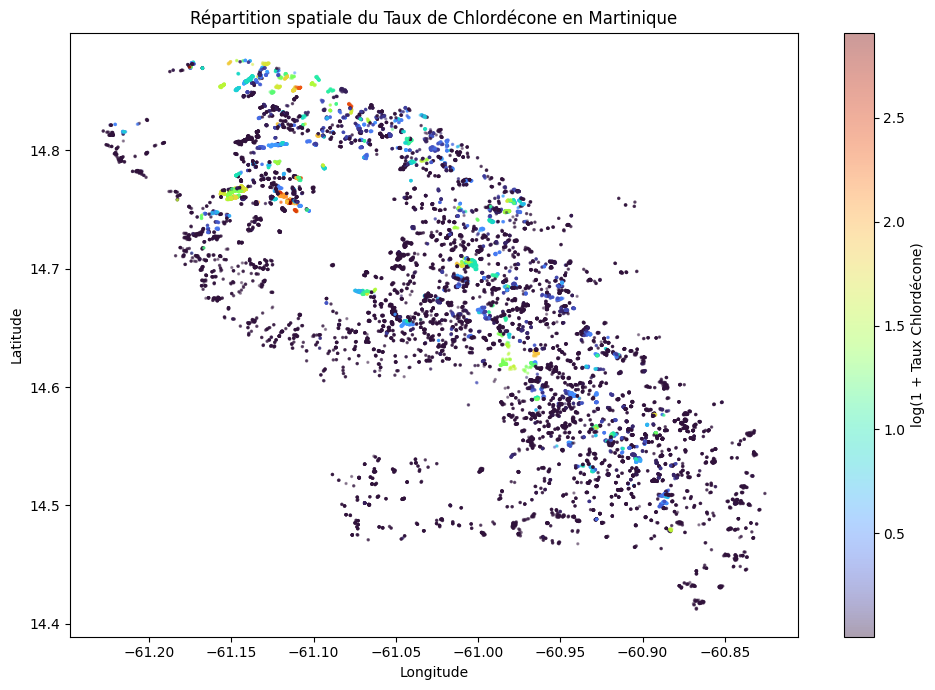

In [3]:
plt.figure(figsize=(10, 7))

# Échelle log pour éviter que les valeurs extrêmes écrasent les autres points
sc = plt.scatter(df['lon'], df['lat'], c=df['log_Taux'], cmap='turbo', alpha=0.4, s=2)
plt.colorbar(sc, label='log(1 + Taux Chlordécone)')
plt.title('Répartition spatiale du Taux de Chlordécone en Martinique')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_carte_statique.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Agrégation par commune

In [4]:
# Agrégation par commune pour obtenir une moyenne du taux de chlordécone par commune
agg_commune = df.groupby('COMMU_LAB').agg(
    taux_moyen = ('Taux_Chlordecone', 'mean'),
    nb         = ('Taux_Chlordecone', 'count'),
    lat        = ('lat', 'mean'),
    lon        = ('lon', 'mean')
).reset_index()

# Affichage des 10 communes avec le taux moyen de chlordécone le plus élevé
agg_commune.sort_values('taux_moyen', ascending=False).head(10)

,COMMU_LAB,taux_moyen,nb,lat,lon
19,MORNE-ROUGE(LE),2.800495,3725,14.766393,-61.134313
11,GRAND'RIVIERE,1.839945,125,14.870621,-61.174197
16,MACOUBA,1.696628,698,14.860080,-61.140506
2,BASSE-POINTE,1.381041,992,14.845138,-61.120966
32,TRINITE(LA),0.684156,1101,14.738917,-60.980227
17,MARIGOT(LE),0.613124,475,14.805574,-61.038574
15,LORRAIN(LE),0.583892,1763,14.817286,-61.071734
27,SAINT-PIERRE,0.561331,339,14.755966,-61.170486
12,GROS-MORNE,0.546698,2093,14.707378,-61.017404
14,LAMENTIN(LE),0.442285,1930,14.639005,-60.987341


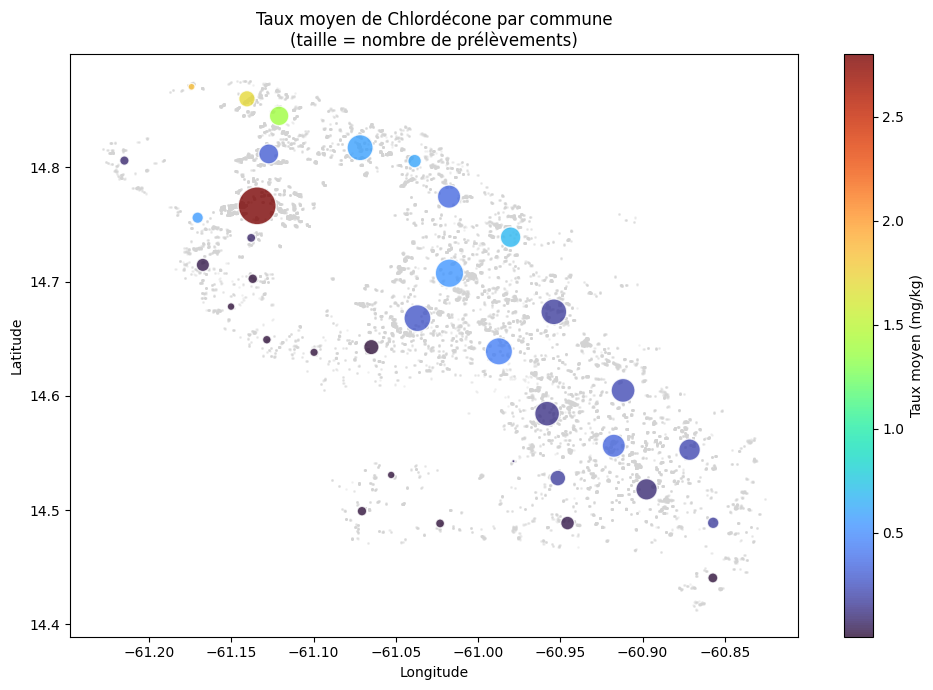

In [5]:
plt.figure(figsize=(10, 7))

# Points de prélèvement en fond gris pour donner une idée de la densité
plt.scatter(df['lon'], df['lat'], color='lightgrey', s=1, alpha=0.2)

# Communes colorées selon le taux moyen, taille selon le nombre de prélèvements
sc = plt.scatter(
    agg_commune['lon'], agg_commune['lat'],
    c=agg_commune['taux_moyen'], cmap='turbo',
    s=agg_commune['nb'] / 5, alpha=0.8, edgecolors='white'
)

plt.colorbar(sc, label='Taux moyen (mg/kg)')
plt.title('Taux moyen de Chlordécone par commune\n(taille = nombre de prélèvements)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_carte_communes.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Carte interactive – Heatmap (Folium)

In [6]:
# Création d'une carte interactive avec Folium
centre = [14.65, -61.02]
carte = folium.Map(location=centre, zoom_start=10, tiles='CartoDB positron')

# Heatmap pour visualiser les zones les plus contaminées
sample = df[['lat', 'lon', 'Taux_Chlordecone']].dropna().sample(5000, random_state=42)
HeatMap(sample.values.tolist(), radius=10, blur=15).add_to(carte)

legende = """
<div style="position:fixed; bottom:30px; right:30px; background:white; padding:12px;
            border:1px solid grey; font-size:13px; z-index:1000; border-radius:5px;">
    <b>Niveau de contamination</b><br>
    <span style="color:#00008B;">■</span> Faible<br>
    <span style="color:#00FF00;">■</span> Modéré<br>
    <span style="color:#FF0000;">■</span> Élevé
</div>
"""

carte.get_root().html.add_child(folium.Element(legende))

# Chemin relatif pour la reproductibilité
carte.save(os.path.join(FIG_DIR, 'carte_heatmap.html'))
carte

## 5. Carte interactive – Marqueurs par commune

In [7]:
# Fonction if/elif/else pour colorier les marqueurs selon le niveau de contamination
def couleur(taux):
    if taux >= 1.0:    return 'red'
    elif taux >= 0.1:  return 'orange'
    else:              return 'green'

carte2 = folium.Map(location=centre, zoom_start=10, tiles='CartoDB positron')

# Un cercle par commune, coloré selon le taux moyen, dimensionné selon le nombre de prélèvements
for _, row in agg_commune.iterrows():
    folium.CircleMarker(
        location     = [row['lat'], row['lon']],
        radius       = max(5, row['nb'] / 200),
        color        = couleur(row['taux_moyen']),
        fill         = True,
        fill_opacity = 0.7,
        popup        = f"{row['COMMU_LAB']} – {row['taux_moyen']:.3f} mg/kg ({int(row['nb'])} prélèvements)"
    ).add_to(carte2)

# Chemin relatif pour la reproductibilité
carte2.save(os.path.join(FIG_DIR, 'carte_communes.html'))
carte2

## 6. Évolution temporelle sur carte

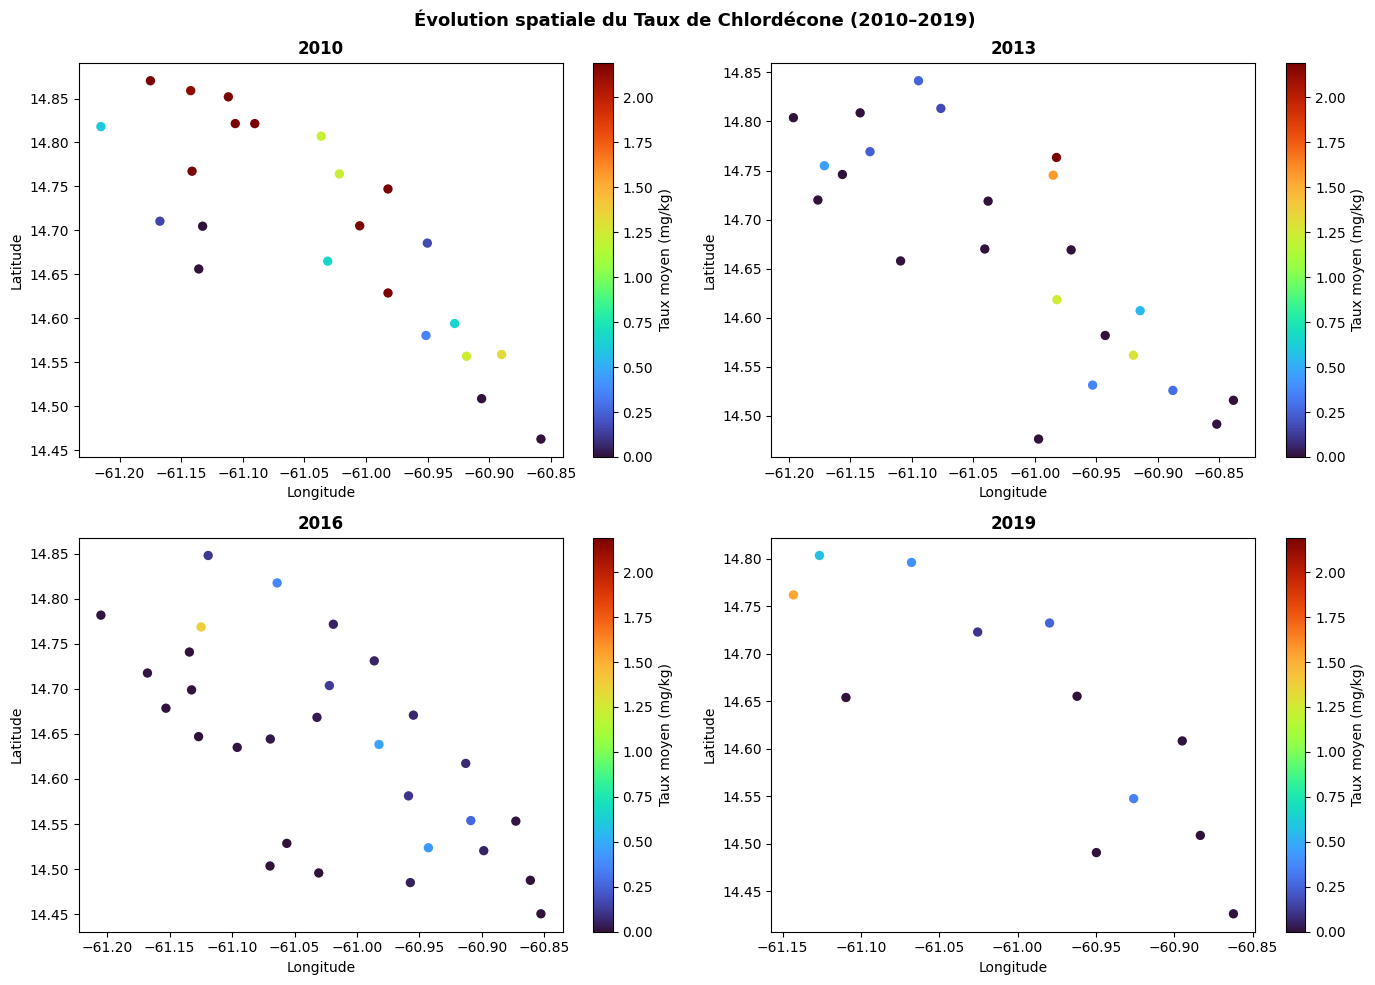

In [8]:
# Agrégation par année et par commune
agg_annee = df.groupby(['ANNEE', 'COMMU_LAB']).agg(
    taux_moyen = ('Taux_Chlordecone', 'mean'),
    lat        = ('lat', 'mean'),
    lon        = ('lon', 'mean')
).reset_index()

# 4 cartes (2×2) pour les années clés
annees = [2010, 2013, 2016, 2019]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Limite supérieure commune à toutes les cartes (95e percentile) pour une échelle cohérente
vmax = agg_annee['taux_moyen'].quantile(0.95)

for i, annee in enumerate(annees):
    sub = agg_annee[agg_annee['ANNEE'] == annee]
    sc = axes[i].scatter(
        sub['lon'], sub['lat'],
        c=sub['taux_moyen'], cmap='turbo',
        vmin=0, vmax=vmax, s=60, edgecolors='white'
    )
    axes[i].set_title(f'{annee}', fontweight='bold')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    plt.colorbar(sc, ax=axes[i], label='Taux moyen (mg/kg)')

plt.suptitle('Évolution spatiale du Taux de Chlordécone (2010–2019)', fontsize=13, fontweight='bold')
plt.tight_layout()
# Chemin relatif pour la reproductibilité
plt.savefig(os.path.join(FIG_DIR, 'fig_evolution_spatiale.png'), dpi=150, bbox_inches='tight')
plt.show()

## Synthèse

Ce notebook a permis de :
- Convertir les coordonnées UTM en latitude/longitude via `pyproj`
- Visualiser la répartition spatiale des parcelles et leur niveau de contamination
- Agréger les données par commune pour une lecture géographique
- Produire des cartes interactives (heatmap et marqueurs) avec `Folium`
- Observer l'évolution temporelle de la contamination sur 4 années clés (2010–2019)

Ces cartes alimenteront la synthèse finale orientée aide à la décision.